In [1]:
# Personalized Learning Path Generator
# Author: Shikha
# Requirements: pandas, numpy, matplotlib, seaborn, scikit-learn, joblib, mysql-connector-python, streamlit
# Step 1: Load Dataset
import pandas as pd
df = pd.read_csv("G9_Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [2]:
# Check missing values
print(df.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [3]:
# Check missing values
print(df.isnull().sum())

# Fill numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Clean categorical column
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype(str).str.strip().str.lower()

# Fill missing before mapping
df['Extracurricular Activities'] = df['Extracurricular Activities'].fillna('no')

# Convert to numeric
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'yes':1, 'no':0})

# Final safety
df['Extracurricular Activities'] = df['Extracurricular Activities'].fillna(0)

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


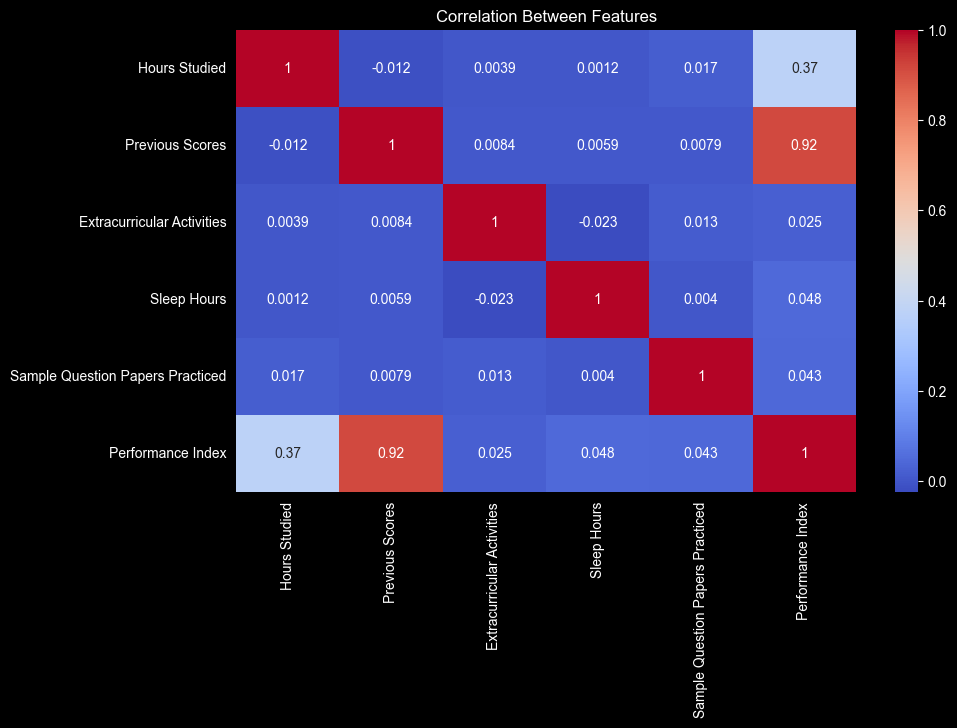

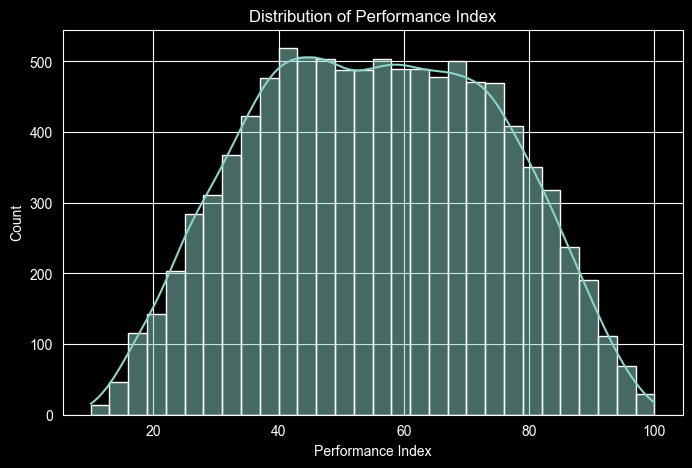

In [13]:
# Step 3: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Features")
plt.show()

# Distribution of Performance Index
plt.figure(figsize=(8,5))
sns.histplot(df['Performance Index'], kde=True, bins=30)
plt.title("Distribution of Performance Index")
plt.show()



In [14]:
# Step 4: Split Features and Target
from sklearn.model_selection import train_test_split

X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Step 5: Train Multiple ML Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2 Score": r2}

results_df = pd.DataFrame(results).T
results_df

,MSE,R2 Score
Linear Regression,4.082628,0.988983
Random Forest,5.158838,0.986079
Gradient Boosting,4.364636,0.988222


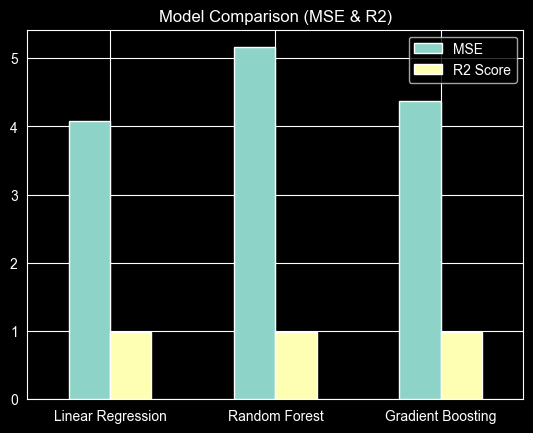

In [16]:
results_df.plot(kind='bar')
plt.title("Model Comparison (MSE & R2)")
plt.xticks(rotation=0)
plt.show()

In [17]:
best_model_name = results_df['R2 Score'].idxmax()
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Linear Regression


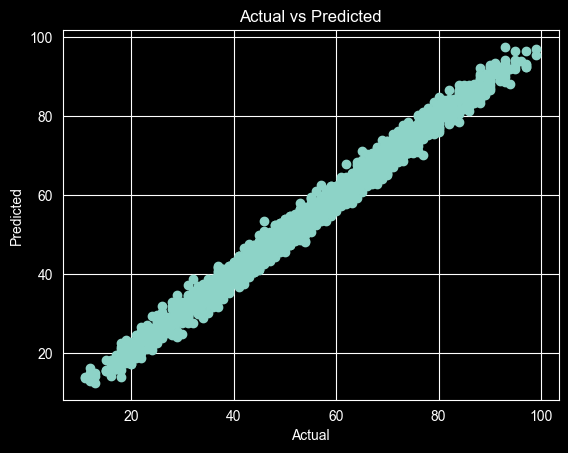

In [18]:
y_pred = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [19]:
def recommend_learning_path(score):
    if score < 40:
        return ["Basic Concepts", "Daily Practice", "Improve Sleep"]
    elif score < 70:
        return ["Intermediate Problems", "Focus Weak Areas", "Mock Tests"]
    else:
        return ["Advanced DSA", "Projects", "Competitive Coding"]

# Example

sample = X_test.iloc[[0]]   # double [[]] keeps it as DataFrame
pred_score = best_model.predict(sample)[0]

print("Predicted Score:", pred_score)
print("Recommendation:", recommend_learning_path(pred_score))

Predicted Score: 54.71185391749008
Recommendation: ['Intermediate Problems', 'Focus Weak Areas', 'Mock Tests']


In [20]:
import joblib

In [21]:
joblib.dump(best_model, "model.pkl")

# Load later
# model = joblib.load("model.pkl")

['model.pkl']